In [48]:
import pandas as pd

In [49]:
df = pd.read_csv("Mall_Customers.csv")

In [50]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [52]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [53]:
df.groupby("Gender")["Spending Score (1-100)"].mean()

Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

In [54]:
df = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

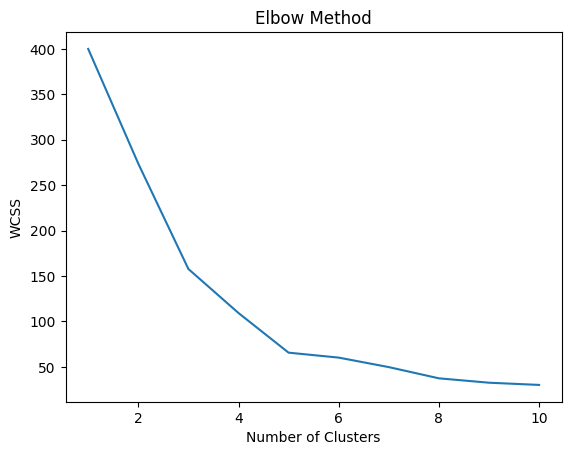

In [56]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [57]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [58]:
df.groupby("Cluster").mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [59]:
def label_cluster(row):
    if row["Annual Income (k$)"] > 60 and row["Spending Score (1-100)"] > 60:
        return "VIP"
    elif row["Annual Income (k$)"] > 60 and row["Spending Score (1-100)"] <= 60:
        return "Potential"
    elif row["Annual Income (k$)"] <= 60 and row["Spending Score (1-100)"] > 60:
        return "High Risk"
    else:
        return "Low Value"

df["Segment"] = df.apply(label_cluster, axis=1)

In [62]:
final_table = df.groupby("Segment", as_index=False).agg({
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "Segment": "size"
})

In [64]:
final_table = df.groupby("Segment", as_index=False).agg({
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
})

In [65]:
final_table["Customer Count"] = df["Segment"].value_counts().values

In [66]:
final_table.columns = ["Segment", "Avg Income", "Avg Spending", "Customer Count"]

In [67]:
final_table.to_excel("Customer_Segmentation_Report.xlsx", index=False)

In [68]:
df.to_excel("Customer_Segmentation_Data.xlsx", index=False)